In [44]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import matplotlib.pyplot as plt
import numpy as np

# Getdata

In [3]:
def load_housing_data():
    tarball_path = Path("datasets/house_prices_dataset.csv")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        #url ="https://github.com/JoannaBroniarek/House-Prices-Advanced-Regression-Techniques/blob/master/dane/train.csv"
    url ="https://raw.githubusercontent.com/JoannaBroniarek/House-Prices-Advanced-Regression-Techniques/master/dane/train.csv"
    data = pd.read_csv(url)
    data.to_csv(tarball_path)
    return data
    

In [4]:
data = load_housing_data()

In [5]:
type(data)

pandas.core.frame.DataFrame

In [6]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


| Column           | Type       | Description |
|------------------|------------|-------------|
| Id               | int        | Unique ID for each house |
| MSSubClass       | int        | Building class |
| MSZoning         | categorical| General zoning classification |
| LotFrontage      | float      | Linear feet of street connected to property |
| LotArea          | int        | Lot size in square feet |
| Street           | categorical| Type of road access (Pave, Grvl) |
| Alley            | categorical| Type of alley access |
| LotShape         | categorical| General shape of property (Reg, IR1, IR2, IR3) |
| LandContour      | categorical| Flatness of property |
| Utilities        | categorical| Utilities available (AllPub, NoSeWa, etc.) |
| LotConfig        | categorical| Lot configuration (Inside, Corner, CulDSac, FR2, FR3) |
| LandSlope        | categorical| Slope of property (Gtl, Mod, Sev) |
| Neighborhood     | categorical| Physical location within Ames city limits |
| Condition1       | categorical| Proximity to main road or railroad |
| Condition2       | categorical| Proximity to second condition (less common) |
| BldgType         | categorical| Type of dwelling (1Fam, 2FmCon, Duplex, etc.) |
| HouseStyle       | categorical| Style of dwelling (1Story, 2Story, SFoyer, SLvl, etc.) |
| OverallQual      | int        | Overall material and finish (1=Poor … 10=Excellent) |
| OverallCond      | int        | Overall condition (1=Poor … 10=Excellent) |
| YearBuilt        | int        | Original construction year |
| YearRemodAdd     | int        | Remodel year (same as YearBuilt if no remodel) |
| RoofStyle        | categorical| Type of roof (Gable, Hip, Mansard, etc.) |
| RoofMatl         | categorical| Roof material |
| Exterior1st      | categorical| Exterior covering on house |
| Exterior2nd      | categorical| Exterior covering on house (if different) |
| MasVnrType       | categorical| Masonry veneer type |
| MasVnrArea       | float      | Masonry veneer area in square feet |
| ExterQual        | categorical| Evaluates exterior material quality |
| ExterCond        | categorical| Evaluates present condition of material |
| Foundation       | categorical| Type of foundation |
| BsmtQual         | categorical| Basement height quality |
| BsmtCond         | categorical| Basement condition |
| BsmtExposure     | categorical| Walkout or garden level exposure |
| BsmtFinType1     | categorical| Quality of basement finished area type 1 |
| BsmtFinSF1       | int        | Type 1 finished square feet |
| BsmtFinType2     | categorical| Quality of basement finished area type 2 |
| BsmtFinSF2       | int        | Type 2 finished square feet |
| BsmtUnfSF        | int        | Unfinished square feet of basement |
| TotalBsmtSF      | int        | Total square feet of basement |
| Heating          | categorical| Type of heating (GasA, GasW, etc.) |
| HeatingQC        | categorical| Heating quality and condition |
| CentralAir       | categorical| Central air conditioning (Y/N) |
| Electrical       | categorical| Electrical system (SBrkr, FuseF, etc.) |
| 1stFlrSF         | int        | First floor square feet |
| 2ndFlrSF         | int        | Second floor square feet |
| LowQualFinSF     | int        | Low quality finished square feet (all floors) |
| GrLivArea        | int        | Above grade living area square feet |
| BsmtFullBath     | int        | Basement full bathrooms |
| BsmtHalfBath     | int        | Basement half bathrooms |
| FullBath         | int        | Full bathrooms above grade |
| HalfBath         | int        | Half bathrooms above grade |
| BedroomAbvGr     | int        | Bedrooms above ground |
| KitchenAbvGr     | int        | Kitchens above ground |
| KitchenQual      | categorical| Kitchen quality |
| TotRmsAbvGrd     | int        | Total rooms above ground (excluding bathrooms) |
| Functional       | categorical| Home functionality (Typ, Min1, Min2, Mod, Maj1, Maj2, Sev, Sal) |
| Fireplaces       | int        | Number of fireplaces |
| FireplaceQu      | categorical| Fireplace quality |
| GarageType       | categorical| Garage location (Attchd, Detchd, BuiltIn…) |
| GarageYrBlt      | float      | Year garage was built |
| GarageFinish     | categorical| Interior finish (Fin, RFn, Unf, NA) |
| GarageCars       | int        | Size of garage in car capacity |
| GarageArea       | int        | Size in square feet |
| GarageQual       | categorical| Garage quality |
| GarageCond       | categorical| Garage condition |
| PavedDrive       | categorical| Paved driveway (Y, P, N) |
| WoodDeckSF       | int        | Wood deck area in square feet |
| OpenPorchSF      | int        | Open porch area in square feet |
| EnclosedPorch    | int        | Enclosed porch area in square feet |
| 3SsnPorch        | int        | Three season porch area in square feet |
| ScreenPorch      | int        | Screen porch area in square feet |
| PoolArea         | int        | Pool area in square feet |
| PoolQC           | categorical| Pool quality |
| Fence            | categorical| Fence quality (GdPrv, MnPrv, etc.) |
| MiscFeature      | categorical| Miscellaneous feature (Elev, Gar2, Shed, etc.) |
| MiscVal          | int        | Value of miscellaneous feature in dollars |
| MoSold           | int        | Month sold (1–12) |
| YrSold           | int        | Year sold (YYYY) |
| SaleType         | categorical| Type of sale (WD, CWD, New, COD, etc.) |
| SaleCondition    | categorical| Condition of sale (Normal, Abnormal, AdjLand, etc.) |
| SalePrice        | int        | Target variable – sale price in dollars |


In [7]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [9]:
data.isna().sum()[lambda x: x>0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [10]:
data['MSZoning'].value_counts()

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

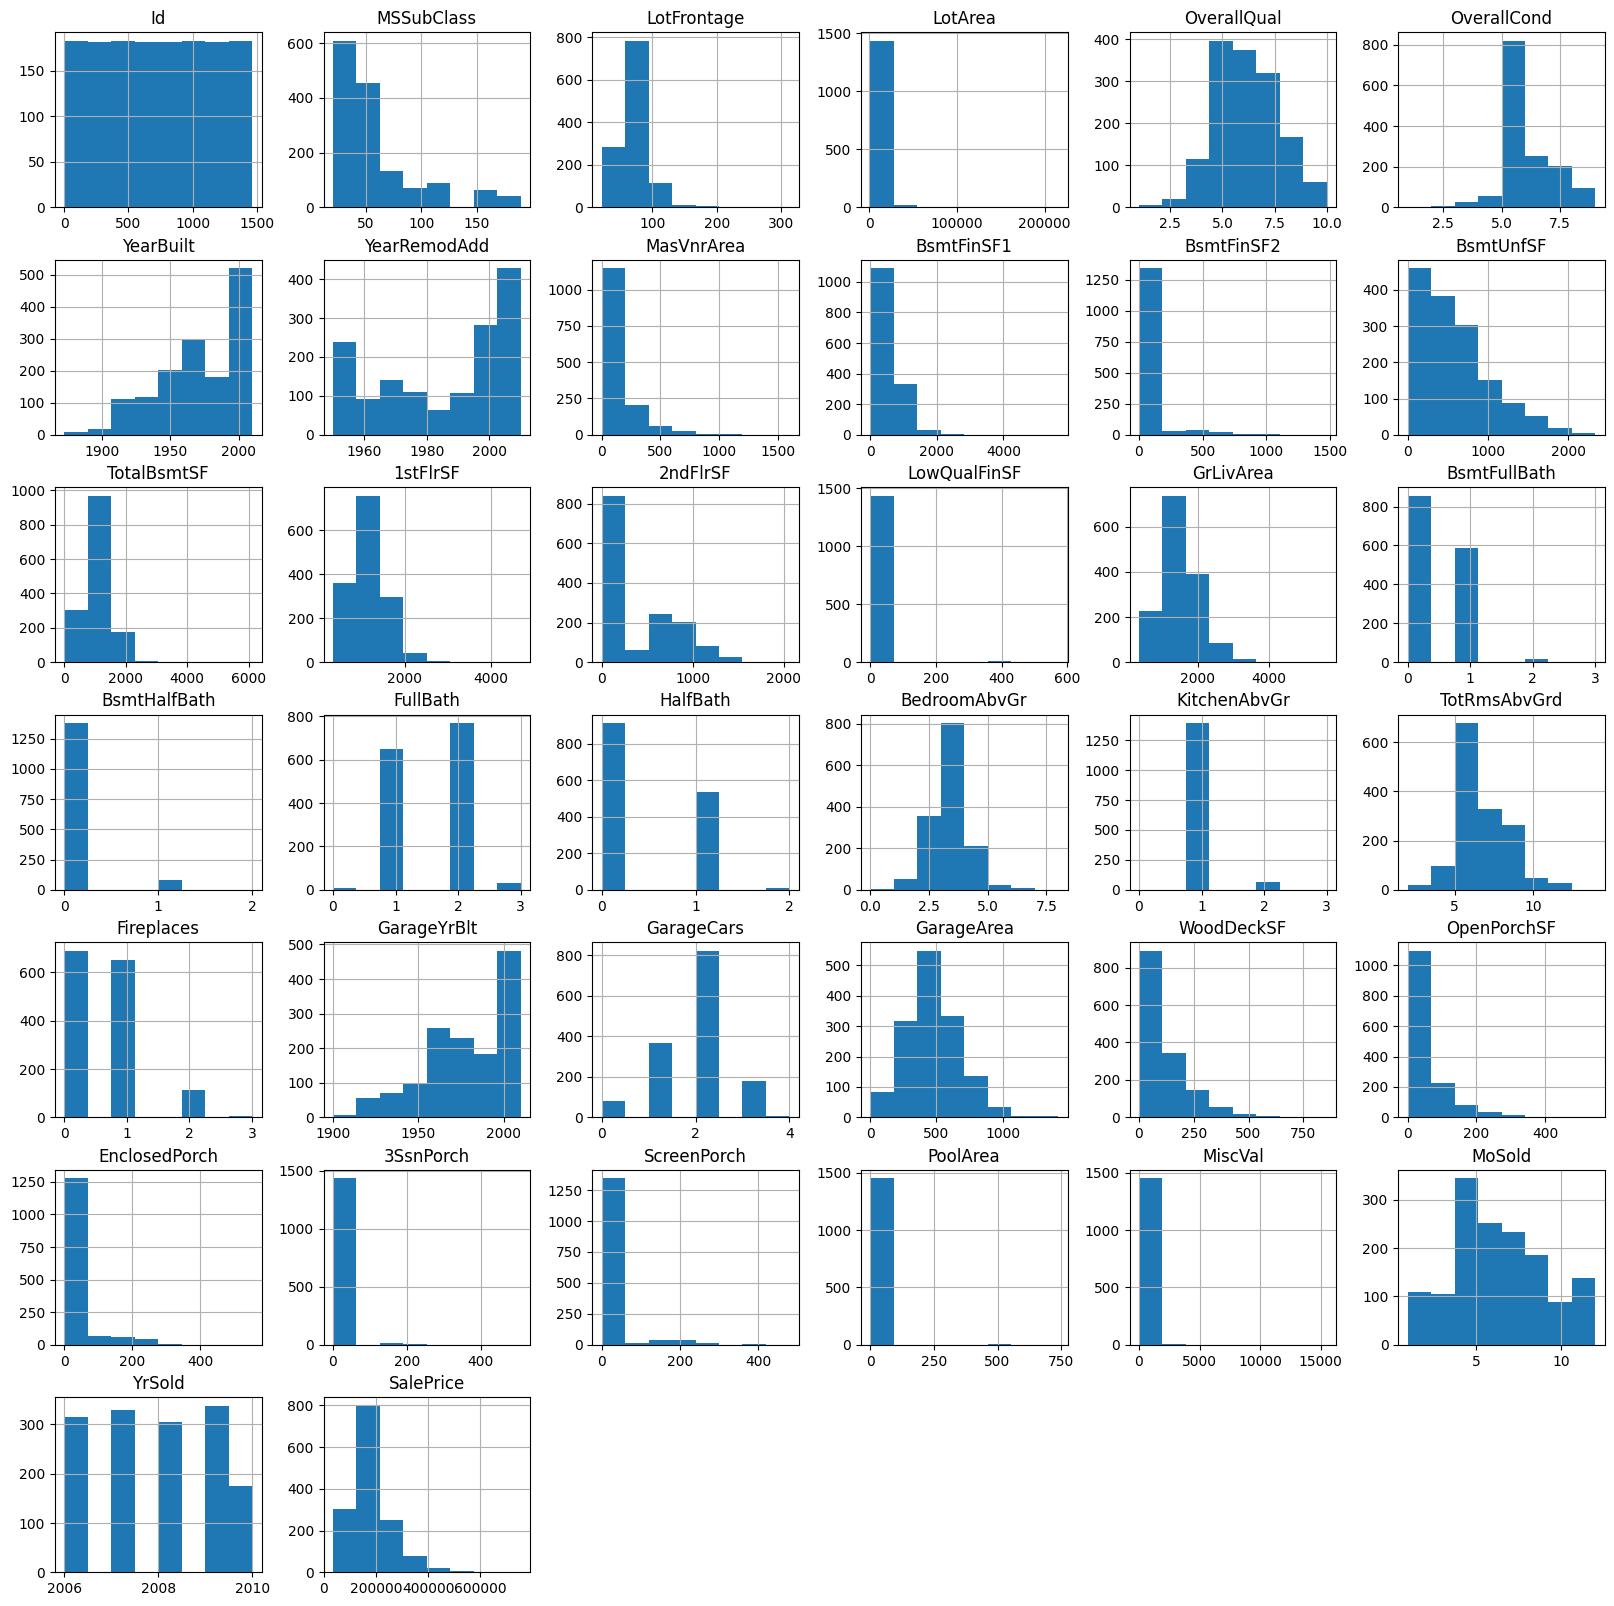

In [28]:
data.hist(bins=8, figsize=(20, 20))
plt.show()

In [42]:
data['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [43]:
data['SalePrice'].value_counts()

SalePrice
140000    20
135000    17
145000    14
155000    14
190000    13
          ..
223000     1
257000     1
282922     1
193879     1
137450     1
Name: count, Length: 663, dtype: int64

In [ ]:
data['Id'].describe()

In [ ]:
data['PoolArea'].describe()

count    1460.000000
mean        2.758904
std        40.177307
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       738.000000
Name: PoolArea, dtype: float64

In [37]:
data['PoolArea'].value_counts()

PoolArea
0      1453
512       1
648       1
576       1
555       1
480       1
519       1
738       1
Name: count, dtype: int64

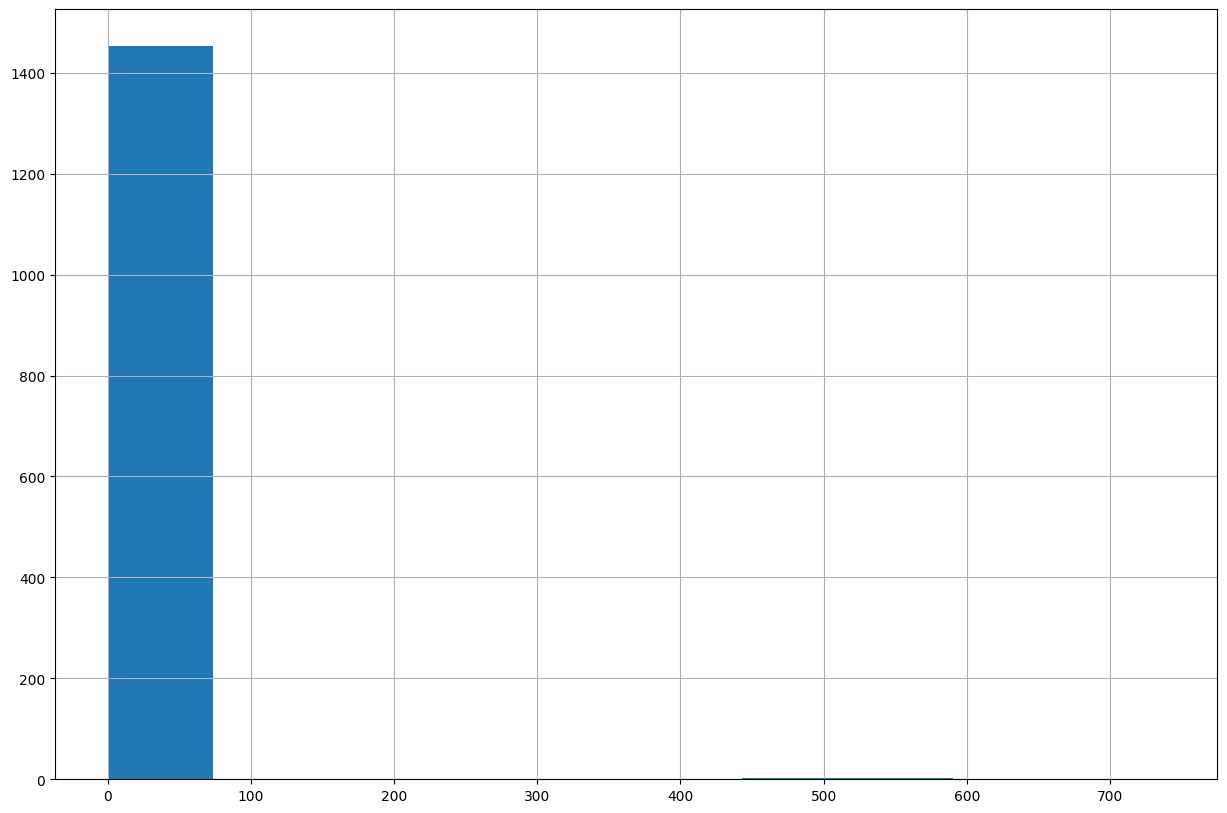

In [41]:
data['PoolArea'].hist(bins=10, figsize=(15, 10))
plt.show()

## Create a Test Set

In [66]:
np.random.seed(42)

In [67]:
def shuffle_and_split_data(data, test_ratio):
    random_index = np.random.permutation(len(data))
    print(random_index)
    test_set_size = int(len(data) * test_ratio)
    test_indices= random_index[:test_set_size]
    train_indices = random_index[test_set_size:]
    return data.iloc[test_indices],data.iloc[train_indices]

In [69]:
test_set,train_set = shuffle_and_split_data(data, 0.2)
print(len(train_set))

print(len(test_set))


[1139 1309  676 ... 1266  884 1333]
1168
292
